# Adjust z

In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
import json
from pathlib import Path
from useful_functions import *

In [2]:
spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectrum = Spectrum(spectra_data, color_data)

In [3]:
# spectrum.subtype_filter(subtype="QSO", exclude=True)

In [4]:
OII_rest    = air2vac(lines_air['OII'])
NII_rest    = air2vac(lines_air['NII'])
Hbeta_rest  = air2vac(lines_air['Hbeta'])
Halpha_rest = air2vac(lines_air['Halpha'])
SII_rest    = air2vac(lines_air['SII'])
CaII_rest   = air2vac(lines_air['CaII'])
NaD_rest    = air2vac(lines_air['NaD'])

39627758300567363
39627763748964089
39627775715312061
39627806128216016
39627824335684933

39627812138650039 is problem

In [715]:
example_targetID = 39627757541396008
example_index = spectrum.id2index(example_targetID)
targetid_example = spectrum.targetID[example_index]
# flux = spectrum.smoothed_flux[example_index, :]
z = spectrum.z_pipe[example_index]

In [716]:
is_qso = check_bits(example_targetID, 2)
print(f'Is QSO? {is_qso}')

Is QSO? False


In [717]:
print(spectrum_link(targetid_example))

https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627757541396008


In [718]:
# spectrum.mask_spectrum(example_index)

In [719]:
flux = spectrum.smoothed_flux[example_index]

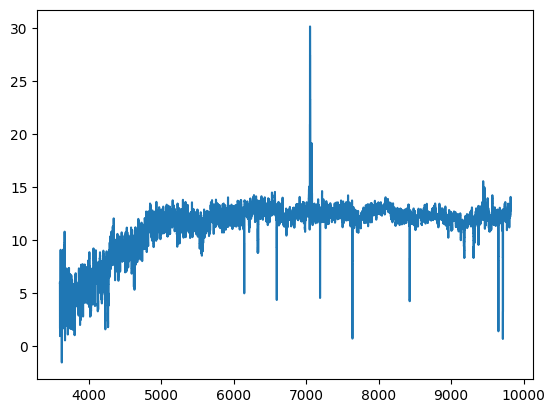

In [720]:
plt.step(desi_wavelength, flux, where='mid')
plt.show()

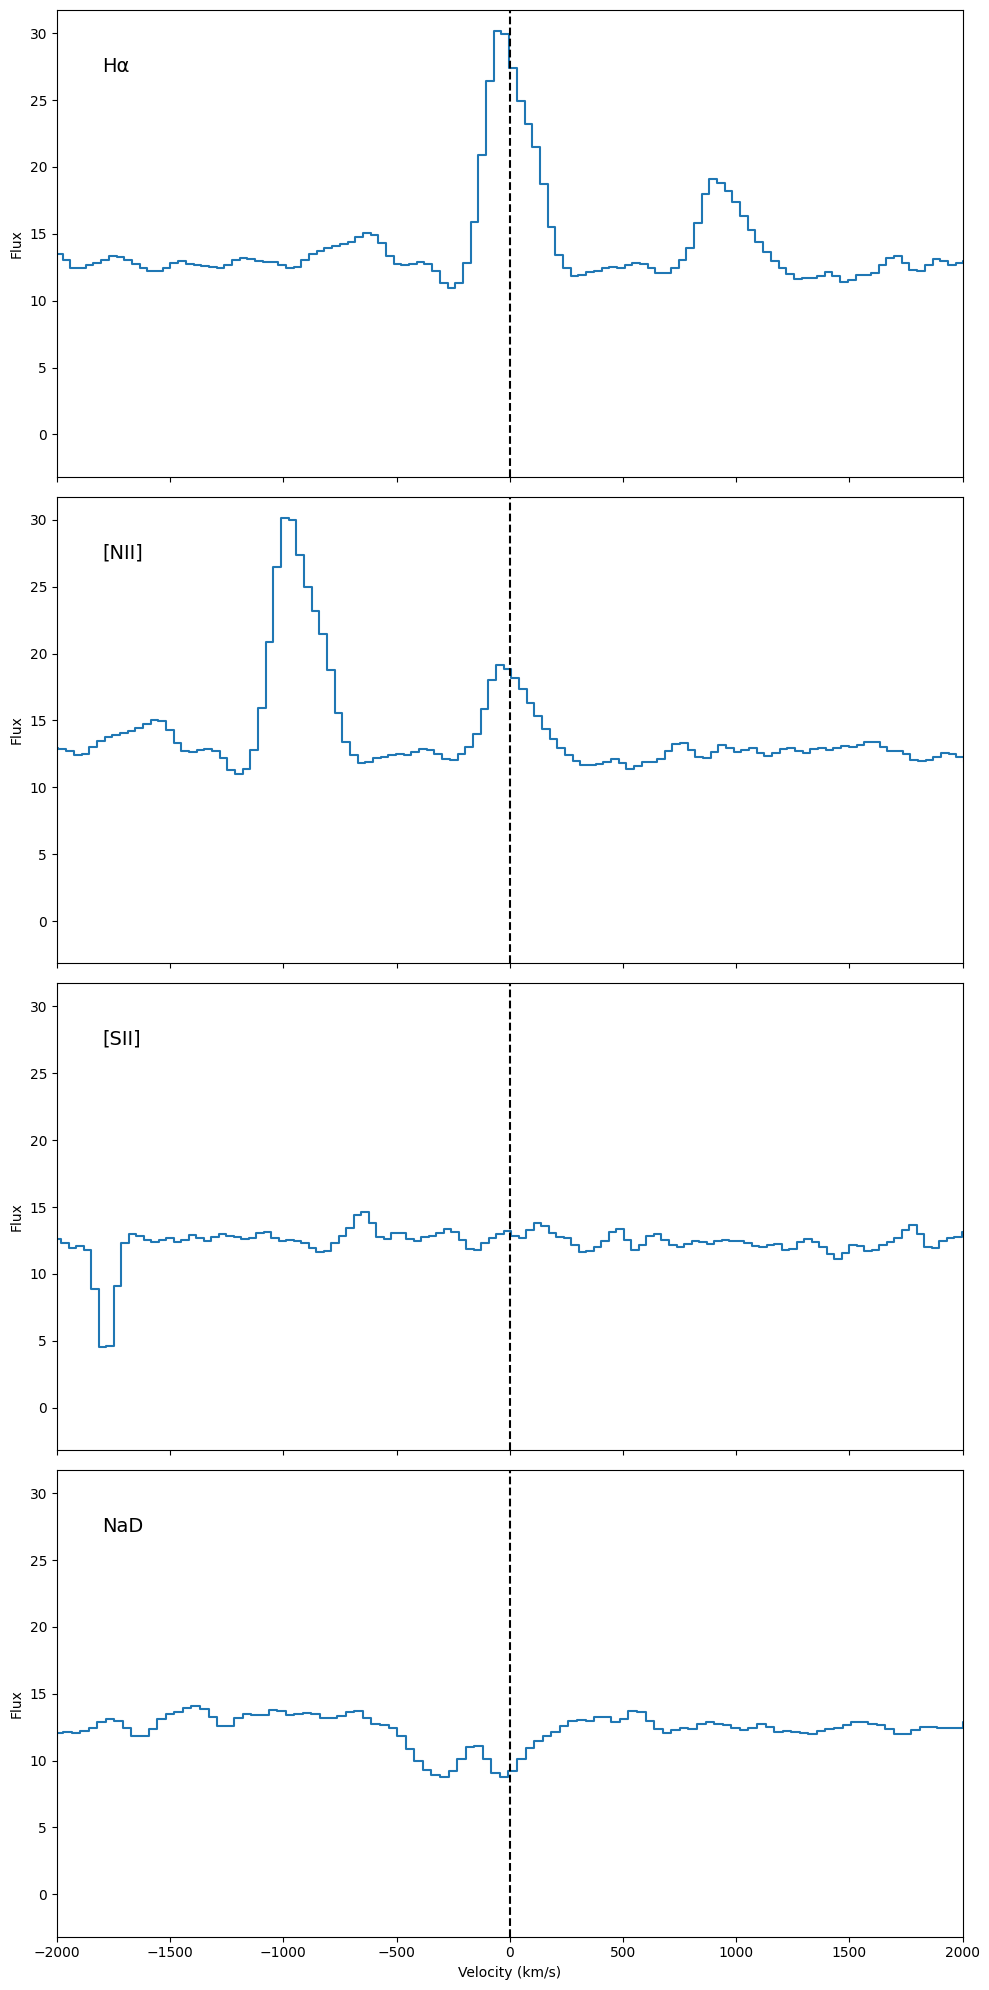

In [722]:
fig, ax = plt.subplots(4, 1, figsize=(10, 20), sharex=True)

# ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z), flux, where='mid')
# ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z), flux, where='mid')
ax[0].step(lam2vel(desi_wavelength, Halpha_rest, z), flux, where='mid')
ax[1].step(lam2vel(desi_wavelength, NII_rest[-1], z), flux, where='mid')
ax[2].step(lam2vel(desi_wavelength, SII_rest[-1], z), flux, where='mid')
# ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z), flux, where='mid')
ax[3].step(lam2vel(desi_wavelength, NaD_rest[-1], z), flux, where='mid')
for i in range(4):
    ax[i].text(0.05, 0.9, ['Hα', '[NII]', '[SII]', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')
plt.tight_layout()
plt.show()

## Fit Halpha + NII (one component)

In [ ]:
fit_line = [
    *Halpha_rest, 
    *NII_rest,
    *SII_rest,
    # *OII_rest
]
mid_lam = np.mean(fit_line) * (1 + z)
region = (np.min(fit_line)*(1 + z)- 200, np.max(fit_line)*(1 + z) + 200)

(0.0, 40.0)

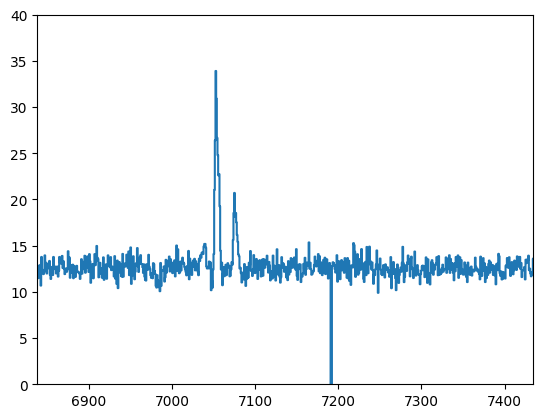

In [ ]:
plt.step(desi_wavelength, spectrum.coadd_data[example_index], where='mid')
plt.axhline(mid_lam, color='k', linestyle='--')
plt.xlim(region[0], region[1])
plt.ylim(0, 40)

In [ ]:
spectrum.fit_flux(i=example_index, fitting_model=model, lam0=fit_line, region=region, fit_z=True)
params = spectrum.fit_params[example_index]

print('dz: '+ f'{params[0]:3f}')
print('================================')
for i in range(len(fit_line)):
    print(f'Amp{i+1}: '+ f'{params[1+2*i]:.3f}')
    print(f'sigma{i+1}: '+ f'{params[2+2*i]:3f}')
print('================================')
print('Conti a: '+ f'{params[2]:3f}')
print('Conti b: '+ f'{params[-1]:3f}')

AttributeError: 'Spectrum' object has no attribute 'fit_params'

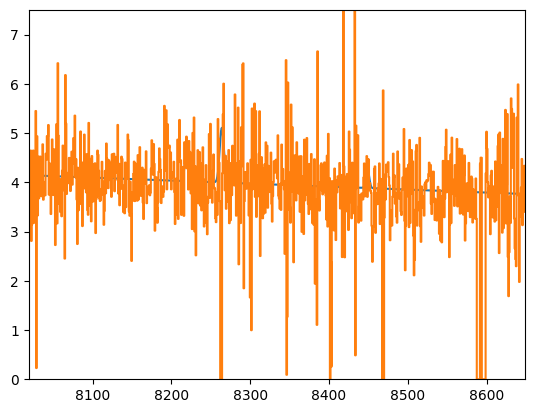

In [ ]:
model_flux = model(desi_wavelength, 
                   gaussian_parms=[(params[2*i+1], fit_line[i]*(1+z+(params[0])), params[2*i+2]) for i in range(len(fit_line))], 
                   conti_parms=(params[-2], params[-1]))

plt.plot(desi_wavelength, (model_flux))
plt.step(desi_wavelength, (spectrum.coadd_data[example_index]), where='mid')
plt.xlim(region[0], region[1])
# plt.xlim(7450, 7550)
plt.ylim(0, np.max(model_flux)*1.1)
plt.savefig('single_component_fit_example.png')
plt.show()

In [ ]:
crop = (region[0] < desi_wavelength) & (desi_wavelength < region[1])
flux_obs = spectrum.coadd_data[example_index][crop]
flux_mod = model_flux[crop]
ivar = spectrum.ivar[example_index][crop]
mask_obs = flux_obs[spectrum.mask[example_index][crop]==0]
mask_mod = flux_mod[spectrum.mask[example_index][crop]==0]
mask_ivar = ivar[spectrum.mask[example_index][crop]==0]

chisq_one = chisq(mask_obs, mask_mod, mask_ivar)
print(f'Chi-square: {chisq_one:.2f}')

Chi-square: 823.39


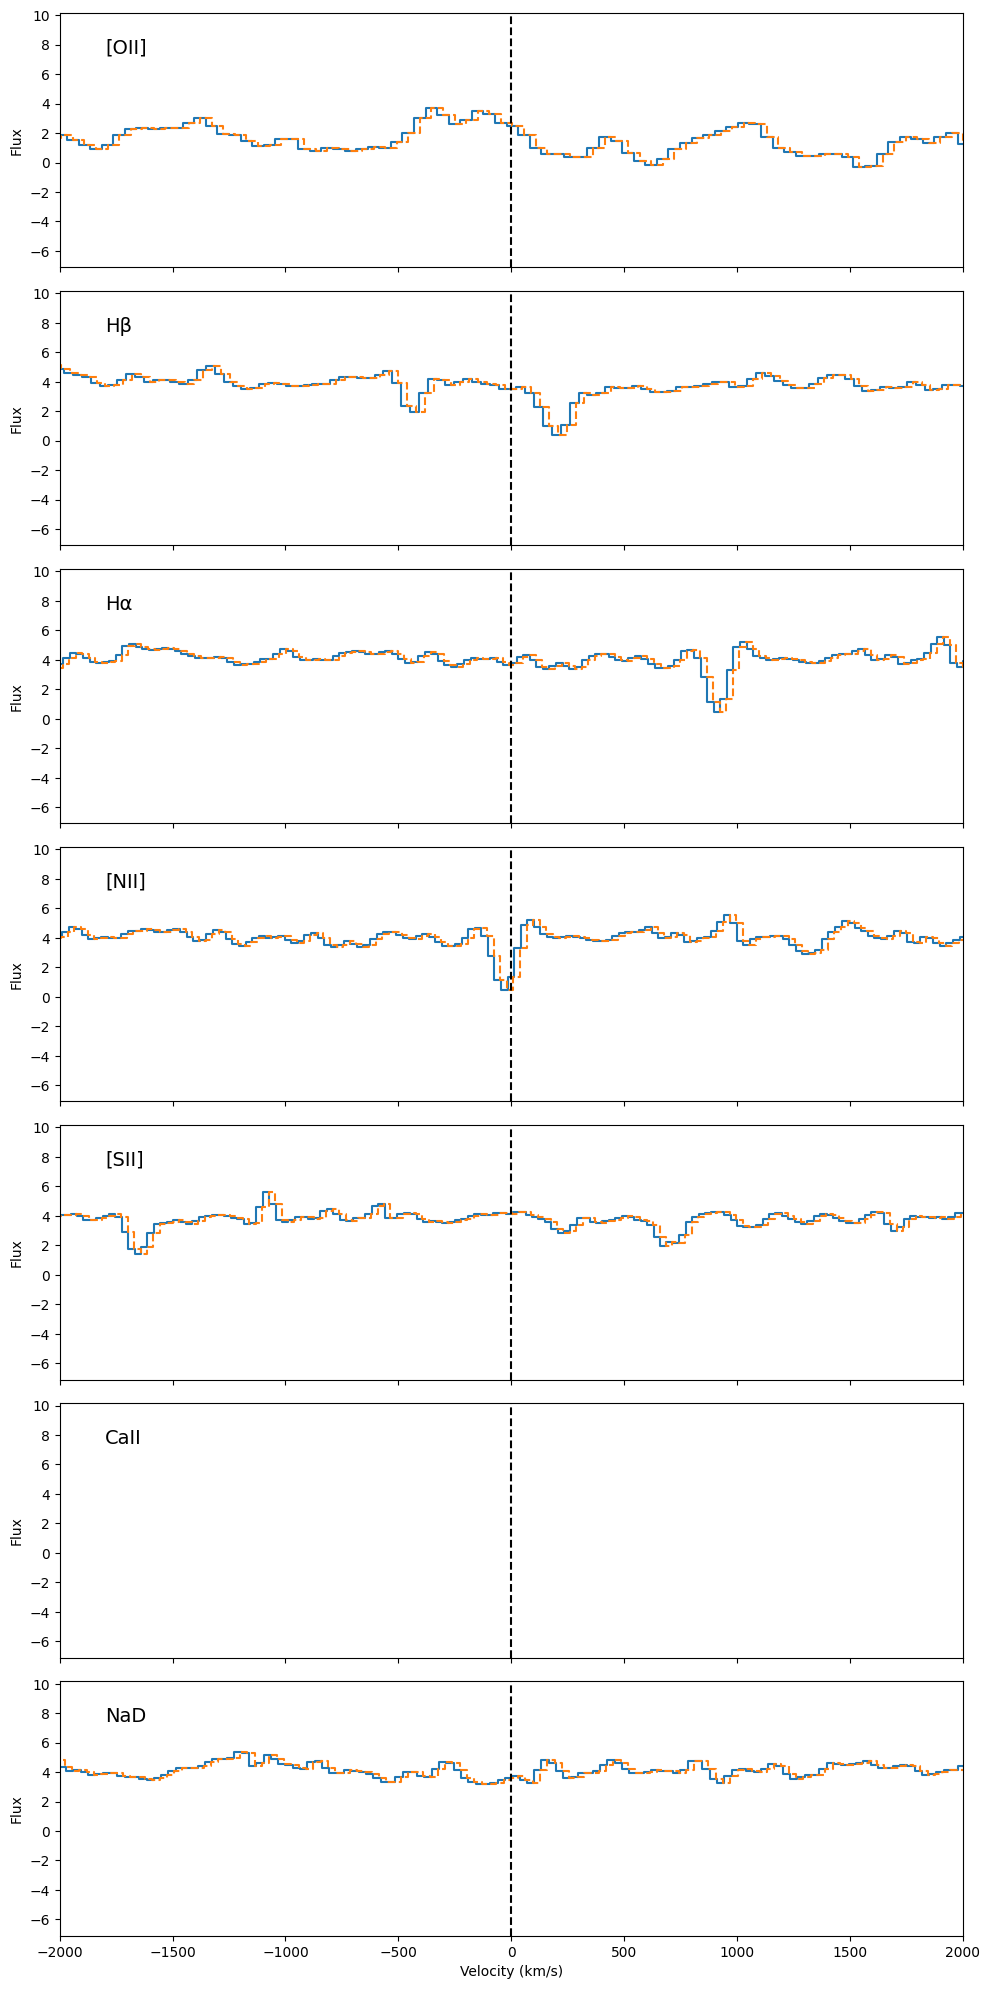

In [ ]:
fig, ax = plt.subplots(7, 1, figsize=(10, 20), sharex=True)

dz_1comp = params[0]
ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z+params[0]), flux, where='mid')
ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z+params[0]), flux, where='mid')
ax[2].step(lam2vel(desi_wavelength, Halpha_rest, z+params[0]), flux, where='mid')
ax[3].step(lam2vel(desi_wavelength, NII_rest[-1], z+params[0]), flux, where='mid')
ax[4].step(lam2vel(desi_wavelength, SII_rest[-1], z+params[0]), flux, where='mid')
ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z+params[0]), flux, where='mid')
ax[6].step(lam2vel(desi_wavelength, NaD_rest[-1], z+params[0]), flux, where='mid')

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z), flux, where='mid', linestyle='--')
ax[1].step(lam2vel(desi_wavelength, Hbeta_rest, z), flux, where='mid', linestyle='--')
ax[2].step(lam2vel(desi_wavelength, Halpha_rest, z), flux, where='mid', linestyle='--')
ax[3].step(lam2vel(desi_wavelength, NII_rest[-1], z), flux, where='mid', linestyle='--')
ax[4].step(lam2vel(desi_wavelength, SII_rest[-1], z), flux, where='mid', linestyle='--')
ax[5].step(lam2vel(desi_wavelength, CaII_rest[-1], z), flux, where='mid', linestyle='--')
ax[6].step(lam2vel(desi_wavelength, NaD_rest[-1], z), flux, where='mid', linestyle='--')

for i in range(7):
    ax[i].text(0.05, 0.9, ['[OII]', 'Hβ', 'Hα', '[NII]', '[SII]', 'CaII', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')
plt.tight_layout()
plt.show()

## Fit Halpha + NII (two components)

In [ ]:
# fit_line = [
#     # *Halpha_rest, 
#     *NII_rest,
#     # *SII_rest,
#     # *OII_rest
# ]
mid_lam = np.mean(fit_line) * (1 + z)
region = (np.min(fit_line)*(1 + z)- 200, np.max(fit_line)*(1 + z) + 200)

In [ ]:
spectrum.fit_flux(i=example_index, 
                  fitting_model=model, 
                  lam0=fit_line, 
                  region=region, 
                  fit_z=True, 
                  two_component=True)
params = spectrum.fit_params[example_index]

print('dz: '+ f'{params[0]:3f}')
print('================================')
for i in range(len(fit_line)):
    print(f'Amp{i+1}: '+ f'{params[1+2*i]:.3f}')
    print(f'sigma{i+1}: '+ f'{params[2+2*i]:3f}')
print('================================')
for i in range(len(fit_line)):
    print(f'Amp{i+1} (2nd comp): '+ f'{params[1+2*i+len(fit_line)]:.3f}')
    print(f'sigma{i+1} (2nd comp): '+ f'{params[2+2*i+len(fit_line)]:3f}')
print('dlam: '+ f'{params[-3]:3f}')
print('================================')
print('Conti a: '+ f'{params[2]:3f}')
print('Conti b: '+ f'{params[-1]:3f}')

dz: 0.000122
Amp1: -0.341
sigma1: 0.849322
Amp2: 0.465
sigma2: 4.246400
Amp3: 1.088
sigma3: 2.721516
Amp4: -0.141
sigma4: 1.793821
Amp5: 0.358
sigma5: 2.398159
Amp1 (2nd comp): 2.722
sigma1 (2nd comp): -0.140997
Amp2 (2nd comp): 1.794
sigma2 (2nd comp): 0.358363
Amp3 (2nd comp): 2.398
sigma3 (2nd comp): -0.634941
Amp4 (2nd comp): 1.850
sigma4 (2nd comp): -0.612480
Amp5 (2nd comp): 0.849
sigma5 (2nd comp): -0.168701
dlam: 4.759702
Conti a: 0.849322
Conti b: 9.114479


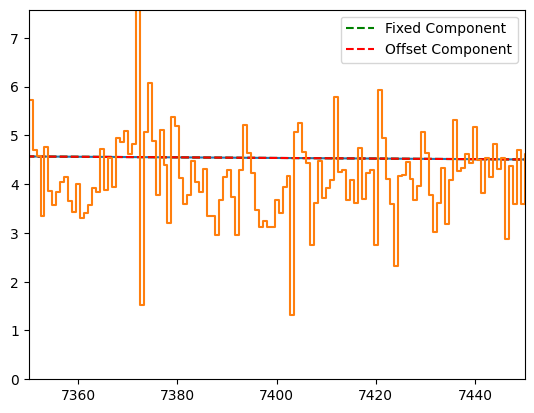

In [ ]:
model_flux = model(desi_wavelength, 
                   gaussian_parms=\
                       [(params[2*i+1], fit_line[i]*(1+z+(params[0])), params[2*i+2]) for i in range(len(fit_line))] +\
                       [(params[2*(i+len(fit_line))+1], (fit_line[i]+params[-3])*(1+z+(params[0])), params[2*(i+len(fit_line))+2]) for i in range(len(fit_line))],
                   conti_parms=(params[-2], params[-1]))

model_flux_fixed = model(desi_wavelength, 
                   gaussian_parms=[(params[2*i+1], fit_line[i]*(1+z+(params[0])), params[2*i+2]) for i in range(len(fit_line))],
                   conti_parms=(params[-2], params[-1]))

model_flux_offset = model(desi_wavelength, 
                   gaussian_parms=[(params[2*(i+len(fit_line))+1], (fit_line[i]+params[-3])*(1+z+(params[0])), params[2*(i+len(fit_line))+2]) for i in range(len(fit_line))],
                   conti_parms=(params[-2], params[-1]))

plt.plot(desi_wavelength, (model_flux))
plt.plot(desi_wavelength, (model_flux_fixed), linestyle='--', color='green', label='Fixed Component')
plt.plot(desi_wavelength, (model_flux_offset), linestyle='--', color='red', label='Offset Component')
plt.step(desi_wavelength, (spectrum.coadd_data[example_index]), where='mid')
plt.xlim(region[0], region[1])
plt.xlim(7350, 7450)
plt.ylim(0, np.max(model_flux)*1.1)
plt.legend()
plt.savefig('two_component_fit_problem.png')
plt.show()

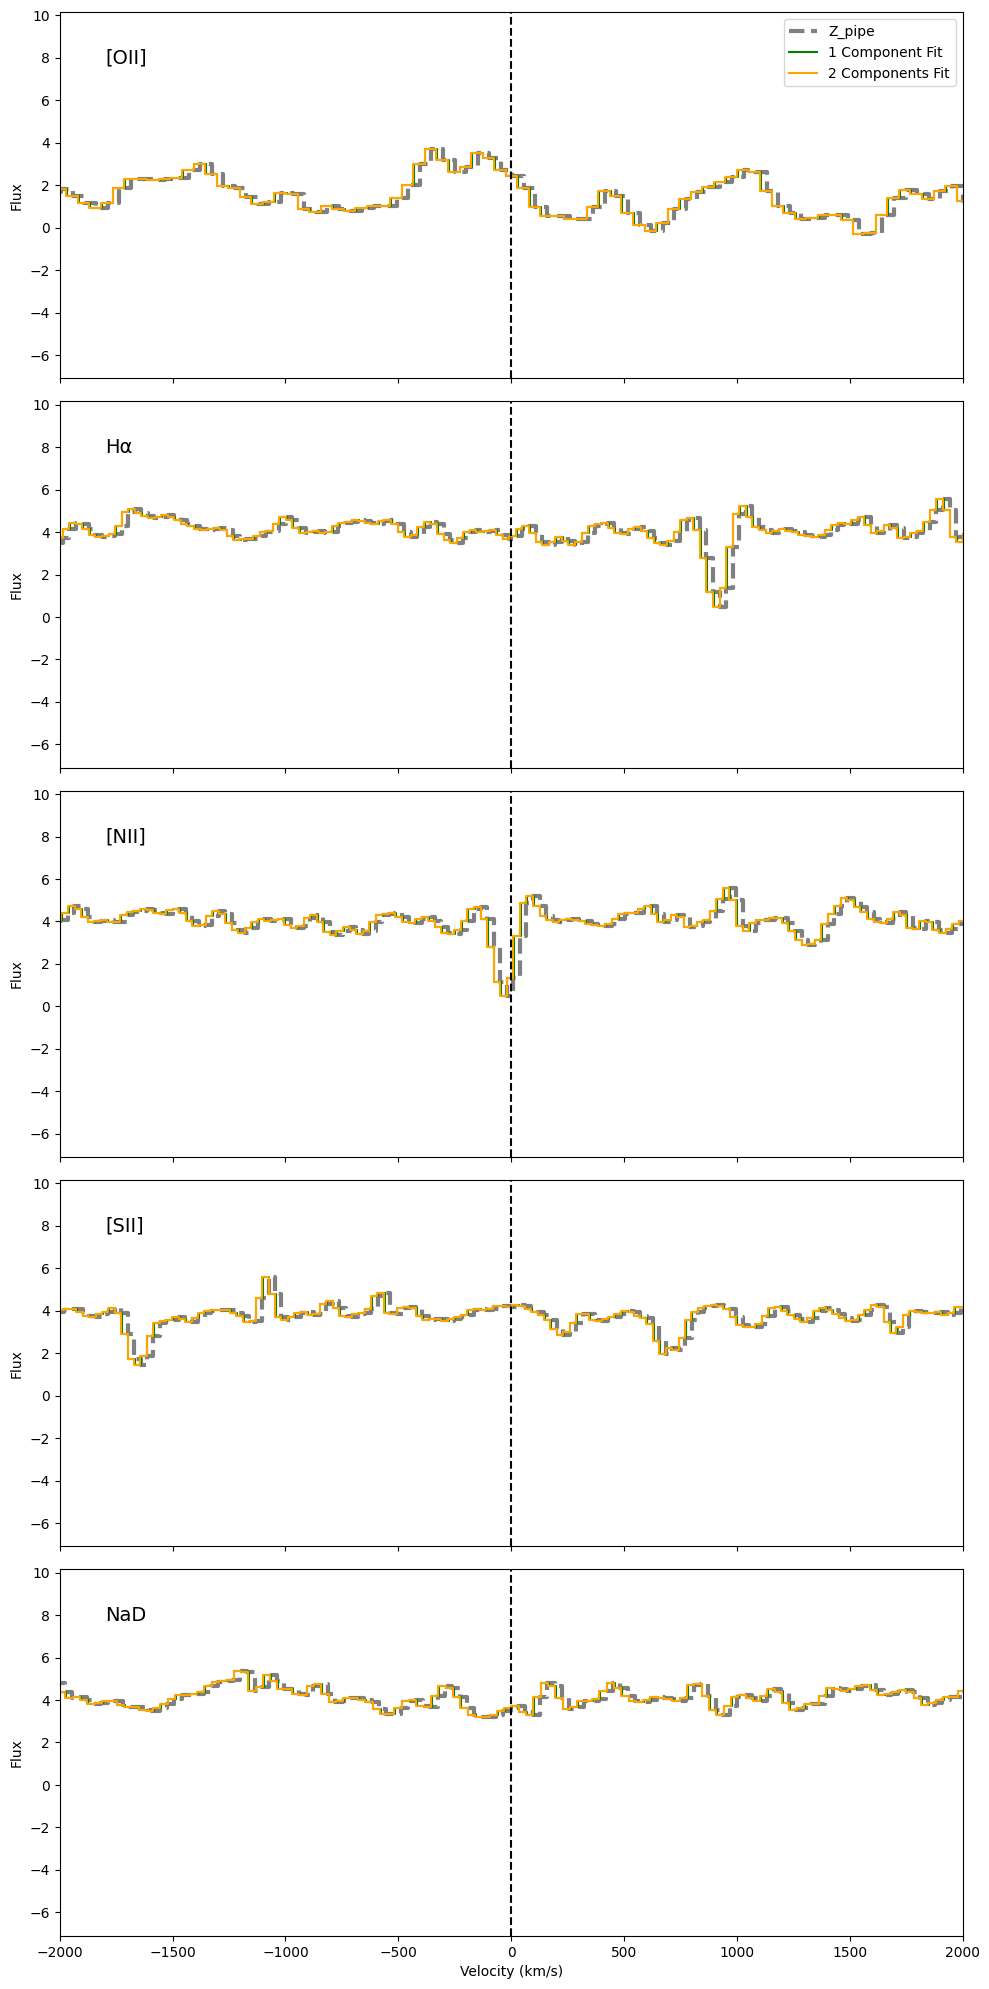

In [ ]:
fig, ax = plt.subplots(5, 1, figsize=(10, 20), sharex=True)

dz_2comp = params[0]

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z), flux, where='mid', linestyle='--', color='gray', label='Z_pipe', linewidth=3)
ax[1].step(lam2vel(desi_wavelength, Halpha_rest, z), flux, where='mid', linestyle='--', color='gray', linewidth=3)
ax[2].step(lam2vel(desi_wavelength, NII_rest[-1], z), flux, where='mid', linestyle='--', color='gray', linewidth=3)
ax[3].step(lam2vel(desi_wavelength, SII_rest[-1], z), flux, where='mid', linestyle='--', color='gray', linewidth=3)
ax[4].step(lam2vel(desi_wavelength, NaD_rest[-1], z), flux, where='mid', linestyle='--', color='gray', linewidth=3)

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z+dz_1comp), flux, where='mid', color='green', label='1 Component Fit')
ax[1].step(lam2vel(desi_wavelength, Halpha_rest, z+dz_1comp), flux, where='mid', color='green')
ax[2].step(lam2vel(desi_wavelength, NII_rest[-1], z+dz_1comp), flux, where='mid', color='green')
ax[3].step(lam2vel(desi_wavelength, SII_rest[-1], z+dz_1comp), flux, where='mid', color='green')
ax[4].step(lam2vel(desi_wavelength, NaD_rest[-1], z+dz_1comp), flux, where='mid', color='green')

ax[0].step(lam2vel(desi_wavelength, OII_rest[-1], z+dz_2comp), flux, where='mid', color='orange', label='2 Components Fit')
ax[1].step(lam2vel(desi_wavelength, Halpha_rest, z+dz_2comp), flux, where='mid', color='orange')
ax[2].step(lam2vel(desi_wavelength, NII_rest[-1], z+dz_2comp), flux, where='mid', color='orange')
ax[3].step(lam2vel(desi_wavelength, SII_rest[-1], z+dz_2comp), flux, where='mid', color='orange')
ax[4].step(lam2vel(desi_wavelength, NaD_rest[-1], z+dz_2comp), flux, where='mid', color='orange')

ax[0].legend()
for i in range(5):
    ax[i].text(0.05, 0.9, ['[OII]', 'Hα', '[NII]', '[SII]', 'NaD'][i], transform=ax[i].transAxes, fontsize=14, verticalalignment='top')
    ax[i].set_xlim(-2000, 2000)
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].set_ylabel('Flux')
ax[-1].set_xlabel('Velocity (km/s)')

plt.tight_layout()
plt.savefig('adjust_z_example.png')
plt.show()

In [ ]:
crop = (region[0] < desi_wavelength) & (desi_wavelength < region[1])
flux_obs = spectrum.coadd_data[example_index][crop]
flux_mod = model_flux[crop]
ivar = spectrum.ivar[example_index][crop]
mask_obs = flux_obs[spectrum.mask[example_index][crop]==0]
mask_mod = flux_mod[spectrum.mask[example_index][crop]==0]
mask_ivar = ivar[spectrum.mask[example_index][crop]==0]

chisq_two = chisq(mask_obs, mask_mod, mask_ivar)
print(f'Chi-square: {chisq_two:.2f}')

Chi-square: 813.98
